# Assignment 2: Milestone I Natural Language Processing
## Task 2&3
#### Student Name: Syeda Shabnam Khan
#### Student ID: s4020189

Date: 17-05-2024

Version: 1.0

Environment: Python 3 and Jupyter notebook

Libraries used: please include all the libraries you used in your assignment, e.g.,:
* pandas
* re
* numpy
* scikit learn
* itertools
* nltk
* scipy
* gensim
* matplotlib

## Introduction

In this part of the assignment we used the preprocessed data from task one to generate feature representation. Then use classification model to train on the features we extracted. Finally, conducted experiments to see how the language models compare and whether more information gives better accuracy.


## Importing libraries 

In [1]:
# Code to import libraries as you need in this assessment, e.g.,
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import gensim.downloader as api
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from nltk.tokenize import sent_tokenize
from itertools import chain
from nltk.tokenize import RegexpTokenizer
from nltk.probability import *
from scipy.sparse import hstack
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")
# to supress the warnings we get

## Task 2. Generating Feature Representations for Job Advertisement Descriptions

In task 2 we take the data saved in task 1 and create feature representation using count vectorizer, gloVe-wiki-gigaword-100 and tf-idf weighted vector with glove-wiki-gigaword-100.

In [3]:
# Reading the data from task 1
data = pd.read_csv('ads.csv')
data.head()

,title,webindex,company,description_raw,description_tk,tokens,target_name,target
0,finance / accounts asst bromley to ****k,68997528,first recruitment services,accountant (partqualified) to **** p.a. south ...,accountant partqualified south east london man...,"['accountant', 'partqualified', 'south', 'east...",Accounting_Finance,0
1,fund accountant hedge fund,68063513,austin andrew ltd,one of the leading hedge funds in london is cu...,hedge funds london recruiting fund accountant ...,"['hedge', 'funds', 'london', 'recruiting', 'fu...",Accounting_Finance,0
2,deputy home manager,68700336,caritas,an exciting opportunity has arisen to join an ...,exciting arisen establish provider elderly car...,"['exciting', 'arisen', 'establish', 'provider'...",Healthcare_Nursing,2
3,brokers wanted imediate start,67996688,onetwotrade,onetwotrade is expanding their sales team and ...,expanding recruiting junior trainee brokers ci...,"['expanding', 'recruiting', 'junior', 'trainee...",Accounting_Finance,0
4,rgn nurses (hospitals) penarth,71803987,swiis healthcare,rgn nurses (hospitals) immediate fulltime and ...,rgn nurses hospitals fulltime part swiis hour ...,"['rgn', 'nurses', 'hospitals', 'fulltime', 'pa...",Healthcare_Nursing,2


In [4]:
# Converting our tokenized description to a list
# this is requireds because count vectorizer takes a list as argument
tk_ads = data['description_tk'].tolist()

In [5]:
# using the file saved in task 1
with open('vocab.txt', 'r') as file:
    # Read the lines of the file into a list
    lines = file.readlines()

# extract each line into a list of word
# and a list of index
vocab = [(line.strip().split(':')[0]) for line in lines]
vocab_index =[(line.strip().split(':')[1]) for line in lines]

In [6]:
# to ensure the features are aligned with task 1
# make a dictionary of the vocabulary with index
vocab_dict = {word: idx for word, idx in zip(vocab, vocab_index)}
# makes a orderless directory of word and its corresponding index

In [7]:
tokens = data['tokens']
tokens

0      ['accountant', 'partqualified', 'south', 'east...
1      ['hedge', 'funds', 'london', 'recruiting', 'fu...
2      ['exciting', 'arisen', 'establish', 'provider'...
3      ['expanding', 'recruiting', 'junior', 'trainee...
4      ['rgn', 'nurses', 'hospitals', 'fulltime', 'pa...
                             ...                        
771    ['today', 'start', 'tomorrow', 'money', 'caree...
772    ['main', 'purpose', 'perform', 'range', 'mecha...
773    ['associate', 'hip', 'knee', 'orthopaedics', '...
774    ['mobile', 'optometrist', 'providers', 'domici...
775    ['title', 'field', 'executive', 'office', 'sup...
Name: tokens, Length: 776, dtype: object

#### Using count vector

In [8]:
# initiating the count vectorizer
cVec = CountVectorizer(analyzer = "word",vocabulary = vocab)

In [9]:
# fitting the list of tokens to count vectorizer
features_cv = cVec.fit_transform(tk_ads)
features_cv.shape

(776, 5168)

In [10]:
# defining a function to print the word and their corresponding 
# values from vectoring
def print_vector(vector_output,idx=0):
    for word, value in zip(vocab, vector_output.toarray()[idx]): 
        if value > 0:
            print(word+":"+str(value), end =' ')

In [11]:
print_vector(features_cv,2)

absence:2 arisen:1 assist:2 care:4 day:2 delivered:1 deputy:1 description:1 develop:1 district:1 elderly:1 ensure:2 establish:1 exciting:1 flexible:1 gp:1 healthcare:1 home:8 individual:1 lead:1 level:1 liaising:1 manage:1 meet:1 met:1 nurses:1 nvq:1 older:1 passion:1 pattern:1 people:1 proven:1 provider:1 qualifications:1 registered:5 requirements:1 residential:1 residents:2 responsibility:2 running:2 sector:1 shift:1 staff:1 standards:1 supervision:1 supervisory:1 totaljobs:1 

#### Tf-idf vector to calculate the weights

In [12]:
# Initializing the tfidf vectorizer to calculate the
# tfidf weights og the vocabulary
tVec = TfidfVectorizer(analyzer = "word",vocabulary = vocab) # initialised the TfidfVectorizer
tfidf_features = tVec.fit_transform(tk_ads) 
tfidf_features.shape

(776, 5168)

In [13]:
print_vector(tfidf_features,2)

absence:0.2267928365428622 arisen:0.0843030022945612 assist:0.14761274161582852 care:0.2346066581298853 day:0.14121312944897774 delivered:0.10398013973274998 deputy:0.109405470952399 description:0.09043750007817657 develop:0.0615767077527987 district:0.1361746087015214 elderly:0.09521808474843345 ensure:0.11702930584696647 establish:0.09803649651899787 exciting:0.07130682080207701 flexible:0.07488672375588011 gp:0.12209807426107133 healthcare:0.07846662670968321 home:0.555875544476602 individual:0.06992680691756552 lead:0.07945500567461093 level:0.058928136849653874 liaising:0.0939275638469724 manage:0.06547044521719902 meet:0.07660776286327012 met:0.10303211421040422 nurses:0.09154358532834594 nvq:0.10124481713977351 older:0.1133964182714311 passion:0.09879798770223656 pattern:0.1133964182714311 people:0.06369680495399668 proven:0.07130682080207701 provider:0.08514758265538783 qualifications:0.07083764524163282 registered:0.3758242581768879 requirements:0.05810840232447268 residential

In [14]:
# See the the output type of the vectorizer
# this is important because to find weighted vector
#  we need to multiply this output
# inconsistent data format may create issues
type(tfidf_features)

scipy.sparse._csr.csr_matrix

#### GloVe wiki gigaword 100
We decided to go with glove-wiki-gigaword-100 because it is sufficiently light weight to handle in the laptop. Moreover, it is trained on  wikipedia and commoncrawl corpora and generates vector based on the statistical co-occurance of words.

In [15]:
# downloading glove using gensim
gloveVec = api.load('glove-wiki-gigaword-100')

In [16]:
# this gives the 100 vectors for the word flexible
gloveVec['flexible']

array([-0.50959  ,  0.22893  , -0.47561  ,  0.22758  , -0.34765  ,
       -0.38519  , -0.56287  ,  0.17215  , -0.0088043,  0.50875  ,
       -0.12816  , -0.62462  ,  0.26494  , -0.0028101,  0.59645  ,
       -0.39855  , -0.30012  , -0.13467  ,  0.87323  , -1.0724   ,
        0.29569  ,  0.22949  , -0.24136  , -0.29916  ,  0.34773  ,
       -0.14721  , -0.1129   , -0.70201  , -0.68345  ,  0.78007  ,
       -0.67715  ,  1.115    , -0.26359  , -1.0788   ,  0.79033  ,
        0.48598  ,  0.23404  , -0.30581  ,  0.008626 , -0.9443   ,
        0.15876  , -0.49988  ,  0.46985  ,  0.40027  , -0.76918  ,
       -0.70225  , -0.041157 ,  0.20559  ,  0.25299  , -0.32375  ,
       -0.081799 , -0.14498  , -0.011516 ,  0.70155  ,  0.29083  ,
       -0.71914  ,  1.2956   , -0.36165  ,  1.3476   , -0.20482  ,
        0.096196 ,  0.08885  , -0.70451  ,  0.52846  ,  0.50997  ,
       -0.63411  , -0.25894  ,  0.59953  ,  0.078722 , -1.0725   ,
        0.49159  , -0.55793  ,  0.3768   , -0.18879  ,  0.3240

In [17]:
# Function to generate document vector using glove model
# this will give the unweighted vectors
# The code for this function was taken from the class materials
def gen_docVecs(wv,tk_txts): # generate vector representation for documents
    docs_vectors = pd.DataFrame() # creating empty final dataframe
#     we will store the vectors in this dataframe
    for i in range(0,len(tk_txts)):
        tokens = tk_txts[i]
        temp = pd.DataFrame()  # creating a temporary dataframe(store value for 1st doc & for 2nd doc remove the details of 1st & proced through 2nd and so on..)
        for w_ind in range(0, len(tokens)): # looping through each word of a single document and spliting through space
            try:
                word = tokens[w_ind]
                word_vec = wv[word] # if word is present in embeddings then proceed
                temp = temp.append(pd.Series(word_vec), ignore_index = True) # if word is present then append it to temporary dataframe
            except:
                pass
        doc_vector = temp.sum() # take the sum of each column
        docs_vectors = docs_vectors.append(doc_vector, ignore_index = True) # append each document value to the final dataframe
    return docs_vectors

In [18]:
# running the glove model
unweighted_vec =gen_docVecs(gloveVec,tokens)

In [19]:
# any null values?
unweighted_vec.isna().any().sum()

0

In [20]:
unweighted_vec.shape

(776, 100)

In [21]:
# the output is a pandas dataframe
type(unweighted_vec)

pandas.core.frame.DataFrame

#### Tf-idf weighted vector
We will calculate tf-idf weighted vector for the descriptions

In [22]:
# convert sparse matrix to dictionary of keys(dok)
# refer: https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.dok_matrix.todok.html#scipy.sparse.dok_matrix.todok
# https://stackoverflow.com/questions/55373331/how-to-transform-a-scipy-sparse-matrix-to-a-dictionary
dok_matrix = tfidf_features.todok()

In [23]:
dok_matrix

<776x5168 sparse matrix of type '<class 'numpy.float64'>'
	with 62166 stored elements in Dictionary Of Keys format>

In [24]:
dok_matrix.items()
# the dok_matrix is in the form of 
# (document index, term/word index), tfidf value

dict_items([((315, 0), 0.18658013823149833), ((122, 1), 0.08177606403895457), ((323, 1), 0.14446250049682097), ((575, 1), 0.24598822783438706), ((242, 2), 0.09511103963026515), ((273, 2), 0.15659153100085285), ((315, 2), 0.15300776744326508), ((591, 2), 0.19652966319033544), ((609, 2), 0.11068826216926608), ((708, 2), 0.19026833080508793), ((200, 3), 0.09445814663868961), ((275, 3), 0.04946591153425538), ((104, 4), 0.33572378362458916), ((99, 5), 0.19780525598395296), ((139, 5), 0.17369126668901974), ((149, 5), 0.1483131101382962), ((251, 5), 0.10758115048948767), ((271, 5), 0.1246342829748923), ((380, 5), 0.20531377687862773), ((491, 5), 0.20302493475307912), ((279, 6), 0.16893826036756962), ((674, 6), 0.19649224727391615), ((117, 7), 0.08654950815697102), ((192, 7), 0.0664972005860947), ((214, 7), 0.20998783893780718), ((245, 7), 0.06048811256548663), ((453, 7), 0.08034878652112508), ((454, 7), 0.041942658654283295), ((725, 7), 0.10226296164739904), ((746, 7), 0.08294677828342471), (

In [25]:
tfidf_dict = {}

# Populate the dictionary with the TF-IDF weights
# for every item in our dok matrix, we iterate over the 
# document index, term index and tfidf weight
# get the corresponding feature name from the tfidf vectorizer
# if the document is not in the dictionary then put it as a key in dictionary
# then inside that key, save the term and weight as key value pair
for (doc_index, term_index), value in dok_matrix.items():
    # Get the term corresponding to the term_index
    term = tVec.get_feature_names_out()[term_index]
    if doc_index not in tfidf_dict:
        tfidf_dict[doc_index] = {}
    tfidf_dict[doc_index][term] = value

In [26]:
# we now have a dictionary of dictionaries
# this will be used to match and multipy the weights for each token
tfidf_dict[0]

{'accountant': 0.3502015754776559,
 'accounts': 0.2743125663759606,
 'adhoc': 0.13505500519123656,
 'administration': 0.10355998392967496,
 'capacity': 0.13358452883303928,
 'cash': 0.11922830097836144,
 'collection': 0.15345567483632414,
 'communication': 0.070277709564177,
 'considered': 0.09531271318466682,
 'control': 0.17546655943359973,
 'credit': 0.2521261382068481,
 'customer': 0.06996439492867648,
 'daily': 0.10564584937441772,
 'debts': 0.1879711717606833,
 'duties': 0.08294417258358575,
 'east': 0.20514266820633364,
 'email': 0.07884175705492424,
 'exceptional': 0.12835773375082868,
 'fully': 0.1061919231001392,
 'handling': 0.24392130714952515,
 'ideal': 0.08802432794046589,
 'ledger': 0.27321000899167364,
 'letter': 0.12835773375082868,
 'london': 0.16839249893971672,
 'manufacturing': 0.09726367012728679,
 'modern': 0.13218581222143622,
 'negotiating': 0.15985275501239027,
 'offices': 0.11518385918795168,
 'part': 0.07189780182251101,
 'partqualified': 0.173326820839609,


In [27]:
# extended version of the `gen_docVecs` function
def gen_docVecs(wv,tk_txts,tfidf = []): # generate vector representation for documents
    docs_vectors = pd.DataFrame() # creating empty final dataframe
    #stopwords = nltk.corpus.stopwords.words('english') # removing stop words

    for i in range(0,len(tk_txts)):

        temp = pd.DataFrame()  # creating a temporary dataframe(store value for 1st doc & for 2nd doc remove the details of 1st & proced through 2nd and so on..)
        for w_ind in range(0, len(vocab)): # looping through each word of a single document and spliting through space
            try:
                word = vocab[w_ind]
                word_vec = wv[word] # if word is present in embeddings(goole provides weights associate with words(300)) then proceed
                
                if tfidf != []:
                    word_weight = float(tfidf[i][word])
                else:
                    word_weight = 1
                temp = temp.append(pd.Series(word_vec*word_weight), ignore_index = True) # if word is present then append it to temporary dataframe
            except:
                pass
        doc_vector = temp.sum() # take the sum of each column(w0, w1, w2,........w300)
        docs_vectors = docs_vectors.append(doc_vector, ignore_index = True) # append each document value to the final dataframe
    return docs_vectors

In [28]:
weighted_vec =gen_docVecs(gloveVec,tokens,tfidf_dict)

In [29]:
weighted_vec.shape

(776, 100)

In [30]:
weighted_vec.isnull().any().sum()

0

### Saving outputs
Save the count vector representation as per spectification.
- count_vectors.txt

In [31]:
# code to save output data...
def write_vectorFile(data_features,filename):
    num = data_features.shape[0] # the number of document
    out_file = open(filename, 'w') # creates a txt file and open to save the vector representation
    for a_ind in range(0, num): # loop through each article by index
        w_idx = data['webindex'][a_ind]
        out_file.write("#{},".format(w_idx))
        for f_ind in data_features[a_ind].nonzero()[1]: # for each word index that has non-zero entry in the data_feature
            value = data_features[a_ind][0,f_ind] # retrieve the value of the entry from data_features
            out_file.write("{}:{} ".format(f_ind,value)) # write the entry to the file in the format of word_index:value
        out_file.write('\n') # start a new line after each article
    out_file.close() # close the file

In [32]:
cVector_file = "./count_vectors.txt" # file name of the count vector
write_vectorFile(features_cv,cVector_file)

## Task 3. Job Advertisement Classification

In this task we use classification machine learning models to observe the performence of the word vectorization techniques we used.

In [33]:
# First we extract the target values from the pandas dataframe
# and read it as a numpy array to pass to the machine learning model
target = data['target'].values
target[0:5]

array([0, 0, 2, 0, 2], dtype=int64)

In [34]:
# Setting the random seed to ensure that the results are reproduceable
seed = 99

#### Training with count vector
We first use the sparse matrix from count vectorizer

In [35]:
# Splitting our data into 70-30 ratio
# 70% for training and 30% for testing
X_train, X_test, y_train, y_test,train_indices,test_indices =  train_test_split(features_cv, target, 
                                                                                list(range(0,len(target))),test_size=0.3,
                                                                                random_state =seed)

In [36]:
# printing the test train indices
print(f'train: {train_indices}\n\ntest: {test_indices}')

train: [561, 316, 288, 499, 375, 425, 295, 563, 111, 267, 17, 719, 226, 442, 734, 735, 613, 360, 746, 195, 769, 469, 152, 344, 481, 137, 610, 649, 761, 758, 616, 275, 480, 574, 705, 206, 103, 441, 222, 153, 180, 382, 682, 141, 471, 210, 653, 142, 2, 4, 474, 281, 202, 368, 692, 307, 416, 520, 507, 510, 714, 171, 273, 357, 194, 549, 102, 302, 209, 162, 708, 665, 87, 609, 190, 644, 178, 598, 44, 373, 764, 596, 627, 232, 366, 702, 338, 497, 435, 216, 774, 532, 637, 670, 358, 43, 673, 436, 228, 467, 5, 261, 342, 750, 622, 527, 757, 318, 117, 694, 672, 312, 680, 75, 173, 775, 51, 462, 473, 319, 313, 235, 655, 573, 519, 604, 93, 671, 739, 410, 611, 148, 660, 249, 340, 691, 200, 689, 91, 220, 28, 439, 72, 715, 748, 280, 89, 685, 468, 182, 175, 335, 533, 666, 270, 586, 703, 109, 572, 688, 461, 322, 80, 720, 659, 333, 553, 63, 61, 372, 278, 701, 225, 279, 635, 337, 227, 186, 8, 85, 42, 558, 552, 640, 96, 341, 676, 156, 33, 512, 121, 693, 211, 293, 664, 624, 565, 236, 164, 566, 393, 453, 282, 364

In [37]:
# we fit the training data
model = LogisticRegression(random_state=seed)
model.fit(X_train, y_train)

LogisticRegression(random_state=99)

In [38]:
# this gives theaccuracy score of the model using test data
# pretty good accuracy
count_accuracy =model.score(X_test,y_test)
count_accuracy

0.8755364806866953

#### Training with  unweighted glove-wiki-100
We will use the glove vector this time

In [39]:
# converting pandas df to numpy array
unweighted_glove =unweighted_vec.values
unweighted_glove

array([[ -185.49121 ,   131.3081  ,   133.1913  , ...,  -407.32266 ,
          208.78572 ,   -64.74063 ],
       [ -198.12073 ,   110.233574,   148.30022 , ...,  -389.36407 ,
          196.65883 ,   -75.23773 ],
       [ -234.69217 ,   144.22394 ,   196.23413 , ...,  -494.74255 ,
          272.57037 ,   -73.95442 ],
       ...,
       [ -794.9536  ,   584.61694 ,   597.0585  , ..., -1733.8146  ,
          922.0413  ,  -242.66104 ],
       [ -299.00818 ,   190.73953 ,   219.5781  , ...,  -675.6336  ,
          362.11282 ,   -76.39517 ],
       [ -300.0919  ,   204.60269 ,   234.80916 , ...,  -654.9761  ,
          341.33118 ,   -93.65082 ]], dtype=float32)

In [40]:
unweighted_glove.shape

(776, 100)

In [41]:
type(unweighted_glove)

numpy.ndarray

In [42]:
X_train, X_test, y_train, y_test,train_indices,test_indices =  train_test_split(unweighted_glove, target, list(range(0,len(target))),test_size=0.3,
                                                                                random_state =seed)

In [43]:
# printing the index will show that we have the same split for train-test
# this is done to ensure that the variation is due to the models and not due to the 
# train-test split
print(f'train: {train_indices}\n\ntest: {test_indices}')

train: [561, 316, 288, 499, 375, 425, 295, 563, 111, 267, 17, 719, 226, 442, 734, 735, 613, 360, 746, 195, 769, 469, 152, 344, 481, 137, 610, 649, 761, 758, 616, 275, 480, 574, 705, 206, 103, 441, 222, 153, 180, 382, 682, 141, 471, 210, 653, 142, 2, 4, 474, 281, 202, 368, 692, 307, 416, 520, 507, 510, 714, 171, 273, 357, 194, 549, 102, 302, 209, 162, 708, 665, 87, 609, 190, 644, 178, 598, 44, 373, 764, 596, 627, 232, 366, 702, 338, 497, 435, 216, 774, 532, 637, 670, 358, 43, 673, 436, 228, 467, 5, 261, 342, 750, 622, 527, 757, 318, 117, 694, 672, 312, 680, 75, 173, 775, 51, 462, 473, 319, 313, 235, 655, 573, 519, 604, 93, 671, 739, 410, 611, 148, 660, 249, 340, 691, 200, 689, 91, 220, 28, 439, 72, 715, 748, 280, 89, 685, 468, 182, 175, 335, 533, 666, 270, 586, 703, 109, 572, 688, 461, 322, 80, 720, 659, 333, 553, 63, 61, 372, 278, 701, 225, 279, 635, 337, 227, 186, 8, 85, 42, 558, 552, 640, 96, 341, 676, 156, 33, 512, 121, 693, 211, 293, 664, 624, 565, 236, 164, 566, 393, 453, 282, 364

In [44]:
# fitting the glove vectors this time
model.fit(X_train, y_train)

LogisticRegression(random_state=99)

In [45]:
# the accuracy is quite low
unglo_accuracy =model.score(X_test,y_test)
unglo_accuracy

0.5450643776824035

#### Weighted Glove
Finally we see test the weighted vector we calculated.

In [46]:
# converting pandas df to numpy array
weighted_glove =weighted_vec.values
weighted_glove

array([[ 0.5700803 ,  0.09474421,  1.2653265 , ..., -0.97531575,
         2.8870418 ,  0.12939127],
       [ 0.52154   ,  0.7595209 ,  0.2234702 , ..., -0.70940363,
         1.5905972 ,  0.48422363],
       [ 0.04576487,  0.5446701 ,  0.8336848 , ..., -0.60004526,
         2.5795343 , -0.16512653],
       ...,
       [-0.02066543,  1.2596246 ,  0.01024736, ..., -2.2882924 ,
         4.9128456 ,  1.4266865 ],
       [-1.313374  ,  0.7969867 ,  0.8259326 , ..., -0.96746945,
         3.3768082 , -0.46749097],
       [-0.03881963,  0.7248649 ,  1.4499131 , ..., -0.5064826 ,
         3.3026052 ,  0.7974017 ]], dtype=float32)

In [47]:
X_train, X_test, y_train, y_test,train_indices,test_indices =  train_test_split(weighted_glove, target, list(range(0,len(target))),test_size=0.3,
                                                                                random_state =seed)

In [48]:
print(f'train: {train_indices}\n\ntest: {test_indices}')

train: [561, 316, 288, 499, 375, 425, 295, 563, 111, 267, 17, 719, 226, 442, 734, 735, 613, 360, 746, 195, 769, 469, 152, 344, 481, 137, 610, 649, 761, 758, 616, 275, 480, 574, 705, 206, 103, 441, 222, 153, 180, 382, 682, 141, 471, 210, 653, 142, 2, 4, 474, 281, 202, 368, 692, 307, 416, 520, 507, 510, 714, 171, 273, 357, 194, 549, 102, 302, 209, 162, 708, 665, 87, 609, 190, 644, 178, 598, 44, 373, 764, 596, 627, 232, 366, 702, 338, 497, 435, 216, 774, 532, 637, 670, 358, 43, 673, 436, 228, 467, 5, 261, 342, 750, 622, 527, 757, 318, 117, 694, 672, 312, 680, 75, 173, 775, 51, 462, 473, 319, 313, 235, 655, 573, 519, 604, 93, 671, 739, 410, 611, 148, 660, 249, 340, 691, 200, 689, 91, 220, 28, 439, 72, 715, 748, 280, 89, 685, 468, 182, 175, 335, 533, 666, 270, 586, 703, 109, 572, 688, 461, 322, 80, 720, 659, 333, 553, 63, 61, 372, 278, 701, 225, 279, 635, 337, 227, 186, 8, 85, 42, 558, 552, 640, 96, 341, 676, 156, 33, 512, 121, 693, 211, 293, 664, 624, 565, 236, 164, 566, 393, 453, 282, 364

In [49]:
# fitting the weighted vectors
model.fit(X_train, y_train)

LogisticRegression(random_state=99)

In [50]:
# better than unweighted accuracy
w_glo_accuracy =model.score(X_test,y_test)
w_glo_accuracy

0.7939914163090128

#### Using k-fold for validation
We have seen the accuracy for each model so far. The count vector performed nest followed by weighted count vector. We want to make sure this is not because of some lucky random train-test split. Therefore, we will use k-fold to validate our results.

In [51]:
# initiating k folds
num_folds = 5
kf = KFold(n_splits= num_folds, random_state=seed, shuffle = True) # initialise a 5 fold validation
print(kf)

KFold(n_splits=5, random_state=99, shuffle=True)


In [52]:
# function to call the classification model
def evaluate_reg(X_train,X_test,y_train, y_test,seed):
    model = LogisticRegression(random_state=seed)
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

In [53]:
# running the model on all three types of vectors 
# and saving the results as dataframe
num_models = 3
cv_df = pd.DataFrame(columns = ['count','glove','w_glove'],index=range(num_folds)) # creates a dataframe to store the accuracy scores in all the folds

fold = 0
for train_index, test_index in kf.split(list(range(0,len(target)))):
    y_train = [target[i] for i in train_index]
    y_test = [target[i] for i in test_index]

    X_train_count, X_test_count = features_cv[train_index], features_cv[test_index]
    cv_df.loc[fold,'count'] = evaluate_reg(features_cv[train_index],features_cv[test_index],y_train,y_test,seed)
    
    X_train_glo, X_test_glo = unweighted_glove[train_index], unweighted_glove[test_index]
    cv_df.loc[fold,'glove'] = evaluate_reg(unweighted_glove[train_index],unweighted_glove[test_index],y_train,y_test,seed)

    X_train_w_glo, X_test_w_glo = weighted_glove[train_index], weighted_glove[test_index]
    cv_df.loc[fold,'w_glove'] = evaluate_reg(weighted_glove[train_index],weighted_glove[test_index],y_train,y_test,seed)
    
    fold +=1

In [54]:
#  the results shoe count performs better in every instance
cv_df

,count,glove,w_glove
0,0.871795,0.576923,0.788462
1,0.890323,0.548387,0.819355
2,0.864516,0.606452,0.819355
3,0.858065,0.580645,0.8
4,0.864516,0.56129,0.767742


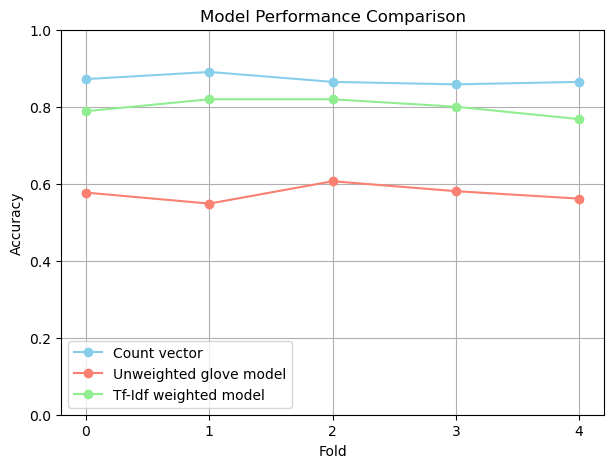

In [55]:
# Plotting the results
plt.figure(figsize=(7, 5))

# Plot each feature representation
plt.plot(cv_df.index, cv_df['count'], marker='o', label='Count vector', color='skyblue')
plt.plot(cv_df.index, cv_df['glove'], marker='o', label='Unweighted glove model', color='salmon')
plt.plot(cv_df.index, cv_df['w_glove'], marker='o', label='Tf-Idf weighted model', color='lightgreen')

# Adding titles and labels
plt.title('Model Performance Comparison', fontsize=12)
plt.xlabel('Fold', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)

# Adding legend
plt.legend(fontsize=10)

# Show the plot
plt.grid(True)
plt.xticks(cv_df.index, fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1)  # Set y-axis range from 0 to 1 for better readability

plt.show()

Based on the results plotted we can see that count vector performs the best. The tf-idf weighted vector using glove performs decently but the unweighted model has quite low accuracy. 

#### To check whether more information is better 
We conduct addition experiment to see if adding the title will give us a better result. But first we will preprocess the title using the same steps as task 1 to ensure rigour in our method.

In [56]:
#  converting the dataframe to list
title = data['title'].tolist()
title

['finance / accounts asst bromley to ****k',
 'fund accountant  hedge fund',
 'deputy home manager',
 'brokers wanted imediate start',
 'rgn nurses (hospitals)  penarth',
 'production coordinator',
 'scrub nurse',
 'sales & purchase ledger clerk  maternity cover',
 'recruitment sales executive',
 'business development executive  field sales  dartford',
 'investments & treasury controller',
 'european payroll',
 'engineering assessor / instructor  south yorkshire',
 'international account manager',
 'senior production technologist (malaysia)',
 'insurance sales executive  horsham',
 'vehicle purchaser / car sales',
 'marine engines specialist – product support',
 'sales manager/medical sales executive',
 'optical assistant  oxfordshire',
 'perm unit mgr rgn kid minster flexi ****k due',
 "perm rgn's in bangor codown  f/t flexi  ****ph exopp  bangor",
 'ecommerce country manager (netherlands)',
 'business development manager  leading financial lending plc',
 'dynamics ax finance consulta

In [57]:
# tokenizing title using the same tokenizer used for task 1
def tokenizeTitle(raw_title):    
    # segament into sentences
    sentences = sent_tokenize(raw_title)
    
    # tokenize each sentence
    pattern = r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"
    tokenizer = RegexpTokenizer(pattern) 
    token_lists = [tokenizer.tokenize(sen) for sen in sentences]
    
    # merge them into a list of tokens
    tokenised_title = list(chain.from_iterable(token_lists))
    return tokenised_title

In [58]:
tk_title = [tokenizeTitle(r) for r in title]
tk_title[0:5]

[['finance', 'accounts', 'asst', 'bromley', 'to', 'k'],
 ['fund', 'accountant', 'hedge', 'fund'],
 ['deputy', 'home', 'manager'],
 ['brokers', 'wanted', 'imediate', 'start'],
 ['rgn', 'nurses', 'hospitals', 'penarth']]

In [59]:
# vocabulary of title
# defining a function to find vocabulary
def vocab_finder(tokenized_list):
    words = list(chain.from_iterable(tokenized_list))
    # vocabulary of all words
    return sorted(list(set(words)))

In [60]:
# Creating the vocabulary for the title
title_vocab = vocab_finder(tk_title)

In [61]:
# Preprocessing title
# making a list of words with lenth less than 2
one_letter_word = []
for word in title_vocab:
    if len(word)<2:
        one_letter_word.append(word)

In [62]:
# difining a filter function
def word_filter(description, filter_list):
    return [w for w in description if w not in filter_list]

In [63]:
# filtering all single letter words
tk_title = [word_filter(t, one_letter_word) for t in tk_title]

In [64]:
# Reading the file for Stopwords
stopwords = []
with open('./stopwords_en.txt') as f:
    stopwords = f.read().splitlines()

In [65]:
# filtering the stopwords
tk_title = [word_filter(t, stopwords) for t in tk_title]

In [66]:
# making a list of words from the tokens to use
# for finding frequency distribution
title_words = list(chain.from_iterable(tk_title))
# using FreqDist from nltk.probability
term_fd = FreqDist(title_words)

# creating a list of words that appear only once
words_once = set(term_fd.hapaxes())

In [67]:
# filtering the words that appear only once
tk_title = [word_filter(t, words_once) for t in tk_title]

In [68]:
list_tk_title = [' '.join(t) for t in tk_title]

In [69]:
# there are some empty string in the list
# not doing any further preprocessing to keep 
# the results consistent with description
list_tk_title

['finance accounts bromley',
 'fund accountant fund',
 'deputy home manager',
 'brokers start',
 'rgn nurses',
 'production coordinator',
 'scrub nurse',
 'sales purchase ledger clerk maternity',
 'recruitment sales executive',
 'business development executive field sales',
 'treasury controller',
 'european payroll',
 'engineering south yorkshire',
 'international account manager',
 'senior production',
 'insurance sales executive',
 'vehicle car sales',
 'marine specialist product support',
 'sales manager medical sales executive',
 'optical assistant',
 'perm unit rgn flexi',
 'perm bangor flexi ph bangor',
 'manager',
 'business development manager leading financial lending plc',
 'dynamics ax finance consultant london',
 'nursing home manager',
 'registered mental nurse rmn',
 'nurses needed care',
 'head financial planning analysis permanent contract',
 'deputy branch manager',
 'professional telesales',
 '',
 'recruitment',
 'support investment bank',
 '',
 'telesales executive'

#### Count vectors for title
For this experiment we are using count vectorizer because it gave us the best accuracy in the previous part. First we find the count vectors for the title. Since we want to see which performs better, title only, title and description or just description, we need a vector for both count and title together. We horizontally stack the vectors we got from title  and description to generate one.

In [70]:
# building the vector on the title vocabulary
cVec2 = CountVectorizer(analyzer = "word",vocabulary = title_vocab)

In [71]:
count_title = cVec2.fit_transform(list_tk_title)
count_title.shape

(776, 1003)

In [72]:
# Combining the sparse matrix we got for title 
# with the one we got for description
combined_count_vectors = hstack((count_title, features_cv))
combined_count_vectors

<776x6171 sparse matrix of type '<class 'numpy.int64'>'
	with 64492 stored elements in Compressed Sparse Row format>

####  Using k-fold to run the regression model on the three sets of feature vectors

In [73]:
num_folds = 5
kf = KFold(n_splits= num_folds, random_state=seed, shuffle = True) # initialise a 5 fold validation
print(kf)

KFold(n_splits=5, random_state=99, shuffle=True)


In [74]:
num_models = 3
cv_df2 = pd.DataFrame(columns = ['description_count', 'title_count', 'combined'],index=range(num_folds)) # creates a dataframe to store the accuracy scores in all the folds

fold = 0
for train_index, test_index in kf.split(list(range(0,len(target)))):
    y_train = [target[i] for i in train_index]
    y_test = [target[i] for i in test_index]
    
    X_train_count, X_test_count = features_cv[train_index], features_cv[test_index]
    cv_df2.loc[fold,'description_count'] = evaluate_reg(features_cv[train_index],features_cv[test_index],y_train,y_test,seed)

    X_train_title, X_test_title = count_title[train_index], count_title[test_index]
    cv_df2.loc[fold,'title_count'] = evaluate_reg(X_train_title, X_test_title,y_train,y_test,seed)
    
    X_train_comb, X_test_comb = combined_count_vectors[train_index], combined_count_vectors[test_index]
    cv_df2.loc[fold,'combined'] = evaluate_reg(X_train_comb, X_test_comb,y_train,y_test,seed)
    
    fold +=1

In [75]:
cv_df2

,description_count,title_count,combined
0,0.871795,0.782051,0.865385
1,0.890323,0.851613,0.883871
2,0.864516,0.877419,0.858065
3,0.858065,0.806452,0.890323
4,0.864516,0.832258,0.870968


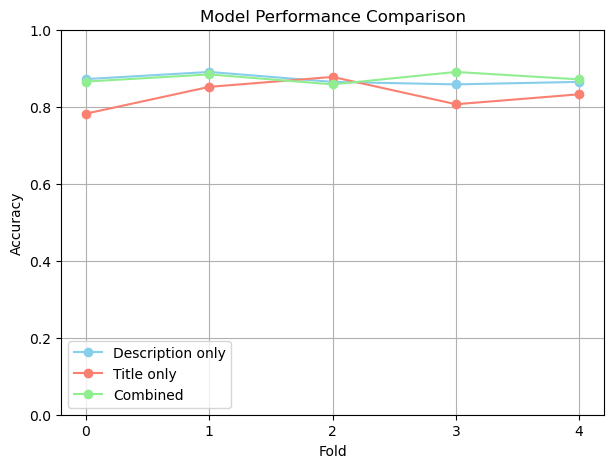

In [76]:
# Plotting the results
plt.figure(figsize=(7, 5))

# Plot each feature representation
plt.plot(cv_df2.index, cv_df2['description_count'], marker='o', label='Description only', color='skyblue')
plt.plot(cv_df2.index, cv_df2['title_count'], marker='o', label='Title only', color='salmon')
plt.plot(cv_df2.index, cv_df2['combined'], marker='o', label='Combined', color='lightgreen')

# Adding titles and labels
plt.title('Model Performance Comparison', fontsize=12)
plt.xlabel('Fold', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)

# Adding legend
plt.legend(fontsize=10)

# Show the plot
plt.grid(True)
plt.xticks(cv_df.index, fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1)  # Set y-axis range from 0 to 1 for better readability

plt.show()

From the plot we can observe that performance of description only and the combination of description and title is quite similar. Although title by itself performs worse the difference in accuracy score is not too wide. It even performs better than the two during third iteration. Based on this we can infer that more information does not necessarily give better performance.

## Summary
In this part of the assessment we vectorized the job ads using 3 techniques and used regression model to classify the documents. Additionally, we answered 2 research questions: which model performs better in terms of accuracy and whether more information is better for classification. Comparing the performance of count vectorizer, glove-wiki-gigaword-100 and tf-idf if glove-wiki-gigaword-100, count vectorizer was the clear winner despite not being able to capture semantics. We used the best performing vectorizing technique to answer the second question. We found that for count vectors more information is not necessarily better.

## References
- COSC2820 Advanced Programming for Data Science. (2024). RMIT University
- How to transform a SciPy sparse matrix to a dictionary. (n.d.). Stack Overflow. Retrieved May 20, 2024, from https://stackoverflow.com/questions/55373331/how-to-transform-a-scipy-sparse-matrix-to-a-dictionary

- Scipy.Sparse.Dok_matrix.Todok — SciPy v1.13.0 manual. (n.d.). Scipy.org. Retrieved May 20, 2024, from https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.dok_matrix.todok.html
